# NIFTY 50 FORECAST (2014-01-01 to 2016-12-31)
This notebook downloads daily NIFTY 50 prices, computes returns, and performs exploratory data analysis.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import itertools
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# Parameters
TICKER = '^NSEI'  # Yahoo ticker for NIFTY 50
START = '2014-01-01'
END = '2016-12-31'
OUT_DIR = os.path.join('..', 'data')
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: ../data


In [4]:
# Download price data and save to CSV
df = yf.download(TICKER, start=START, end=END, progress=False)
if df.empty:
    raise RuntimeError('Data download returned empty DataFrame. Confirm ticker and network access.')
csv_path = os.path.join(OUT_DIR, 'nifty_2014_2016.csv')
df.to_csv(csv_path)
print('Saved:', csv_path)
df.head()

Saved: ../data/nifty_2014_2016.csv


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


In [5]:
df.isnull().sum()

Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64

In [6]:
# Basic inspection
print('Shape:', df.shape)
display(df.describe().round(3))
display(df.info())

Shape: (728, 5)


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
count,728.000,728.000,728.000,728.000,728.000
mean,7917.152,7961.857,7872.440,7923.540,172135.165
std,692.506,695.068,691.867,696.620,51880.215
min,6000.900,6017.800,5933.300,5947.600,75500.000
25%,7624.100,7678.725,7581.950,7636.050,137250.000
50%,8059.000,8106.775,8005.125,8055.250,161600.000
75%,8432.350,8476.963,8380.600,8438.413,191600.000
max,8996.250,9119.200,8925.550,9109.150,473400.000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 728 entries, 2014-01-02 to 2016-12-30
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^NSEI)   728 non-null    float64
 1   (High, ^NSEI)    728 non-null    float64
 2   (Low, ^NSEI)     728 non-null    float64
 3   (Open, ^NSEI)    728 non-null    float64
 4   (Volume, ^NSEI)  728 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.1 KB


None

In [7]:
# Compute returns (simple and log) based on Close price
df = df.assign(Close=df['Close'])
df['return'] = df['Close'].pct_change()
df['log_return'] = np.log(df['Close']).diff()
df['log_price'] = np.log(df['Close'])
returns = df['return'].dropna()
log_returns = df['log_return'].dropna()
print('Computed returns — length:', len(returns))
returns.head()

Computed returns — length: 727


Date
2014-01-03   -0.001607
2014-01-06   -0.003172
2014-01-07   -0.004716
2014-01-08    0.002004
2014-01-09   -0.001012
Name: return, dtype: float64

In [8]:
# Prepare data for ARIMA modeling
# We'll use log returns for modeling as they are more stationary
log_returns.head()

Date
2014-01-03   -0.001609
2014-01-06   -0.003177
2014-01-07   -0.004727
2014-01-08    0.002002
2014-01-09   -0.001013
Name: log_return, dtype: float64

## ARIMA Grid Search
We'll perform a grid search to find the optimal ARIMA(p,d,q) parameters for forecasting NIFTY 50 returns.

In [9]:
def arima_grid_search(data, p_values, d_values, q_values, ic='aic', verbose=True):
    """
    Perform grid search for ARIMA parameters
    
    Parameters:
    -----------
    data : pandas Series
        Time series data to fit
    p_values : list
        Range of p values (autoregressive order)
    d_values : list 
        Range of d values (differencing order)
    q_values : list
        Range of q values (moving average order)
    ic : str
        Information criterion ('aic', 'bic', 'hqic')
    verbose : bool
        Whether to print progress
        
    Returns:
    --------
    results_df : pandas DataFrame
        DataFrame with all parameter combinations and their IC values
    best_params : tuple
        Best (p,d,q) parameters
    best_model : ARIMA
        Fitted ARIMA model with best parameters
    """
    
    # Generate all parameter combinations
    param_combinations = list(itertools.product(p_values, d_values, q_values))
    
    results = []
    best_ic = np.inf
    best_params = None
    best_model = None
    
    if verbose:
        print(f"Testing {len(param_combinations)} parameter combinations...")
        print(f"Optimizing on: {ic.upper()}")
        print("-" * 60)
    
    for i, (p, d, q) in enumerate(param_combinations):
        try:
            # Fit ARIMA model
            model = ARIMA(data, order=(p, d, q))
            fitted_model = model.fit()
            
            # Get information criterion
            if ic.lower() == 'aic':
                ic_value = fitted_model.aic
            elif ic.lower() == 'bic':
                ic_value = fitted_model.bic
            elif ic.lower() == 'hqic':
                ic_value = fitted_model.hqic
            else:
                raise ValueError("ic must be 'aic', 'bic', or 'hqic'")
            
            # Store results
            results.append({
                'p': p, 'd': d, 'q': q,
                'aic': fitted_model.aic,
                'bic': fitted_model.bic, 
                'hqic': fitted_model.hqic,
                'llf': fitted_model.llf,
                'converged': fitted_model.mle_retvals['converged'] if hasattr(fitted_model, 'mle_retvals') else True
            })
            
            # Check if this is the best model so far
            if ic_value < best_ic:
                best_ic = ic_value
                best_params = (p, d, q)
                best_model = fitted_model
            
            if verbose and (i + 1) % 10 == 0:
                print(f"Completed {i + 1}/{len(param_combinations)} combinations...")
                
        except Exception as e:
            if verbose:
                print(f"ARIMA({p},{d},{q}) failed: {str(e)[:50]}...")
            continue
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    if verbose:
        print(f"\nGrid search completed!")
        print(f"Best parameters: ARIMA{best_params}")
        print(f"Best {ic.upper()}: {best_ic:.4f}")
        print(f"Total successful fits: {len(results_df)}")
    
    return results_df, best_params, best_model

In [10]:
# Define parameter ranges for grid search
# Start with reasonable ranges based on typical financial time series
p_values = range(0, 4)  # AR terms: 0, 1, 2, 3
d_values = range(0, 2)  # Differencing: 0, 1 (log returns are usually stationary)
q_values = range(0, 4)  # MA terms: 0, 1, 2, 3

print(f"Parameter ranges:")
print(f"p (AR terms): {list(p_values)}")
print(f"d (Differencing): {list(d_values)}")
print(f"q (MA terms): {list(q_values)}")
print(f"Total combinations: {len(p_values) * len(d_values) * len(q_values)}")

Parameter ranges:
p (AR terms): [0, 1, 2, 3]
d (Differencing): [0, 1]
q (MA terms): [0, 1, 2, 3]
Total combinations: 32


In [11]:
# Run grid search on log returns
print("\nRunning ARIMA grid search on log returns...")
print("=" * 50)

# Use log returns for modeling (they should be more stationary)
data_for_modeling = log_returns.dropna()

# Run grid search
results_df, best_params, best_model = arima_grid_search(
    data=data_for_modeling,
    p_values=p_values,
    d_values=d_values, 
    q_values=q_values,
    ic='aic',  # Use AIC as selection criterion
    verbose=True
)


Running ARIMA grid search on log returns...
Testing 32 parameter combinations...
Optimizing on: AIC
------------------------------------------------------------
Completed 10/32 combinations...
Completed 10/32 combinations...
Completed 20/32 combinations...
Completed 20/32 combinations...
Completed 30/32 combinations...
Completed 30/32 combinations...

Grid search completed!
Best parameters: ARIMA(1, 0, 1)
Best AIC: -4731.6774
Total successful fits: 32

Grid search completed!
Best parameters: ARIMA(1, 0, 1)
Best AIC: -4731.6774
Total successful fits: 32


In [12]:
# Display top 10 models by AIC
print("\nTop 10 models by AIC:")
print("=" * 40)
top_models = results_df.sort_values('aic').head(10)
display(top_models[['p', 'd', 'q', 'aic', 'bic', 'hqic', 'converged']].round(4))

# Display best model summary
print(f"\n\nBest Model: ARIMA{best_params}")
print("=" * 40)
print(best_model.summary())


Top 10 models by AIC:


,p,d,q,aic,bic,hqic,converged
9,1,0,1,-4731.6774,-4713.3217,-4724.5943,True
3,0,0,3,-4729.9999,-4707.0553,-4721.1460,True
10,1,0,2,-4729.6124,-4706.6677,-4720.7585,True
2,0,0,2,-4729.3692,-4711.0135,-4722.2861,False
24,3,0,0,-4728.9959,-4706.0513,-4720.1420,True
18,2,0,2,-4728.3365,-4700.8029,-4717.7118,True
11,1,0,3,-4727.9458,-4700.4122,-4717.3211,True
16,2,0,0,-4727.7978,-4709.4421,-4720.7147,True
1,0,0,1,-4727.5555,-4713.7887,-4722.2431,True
25,3,0,1,-4727.2811,-4699.7475,-4716.6564,True




Best Model: ARIMA(1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                  727
Model:                 ARIMA(1, 0, 1)   Log Likelihood                2369.839
Date:                Sat, 15 Nov 2025   AIC                          -4731.677
Time:                        23:13:15   BIC                          -4713.322
Sample:                             0   HQIC                         -4724.594
                                - 727                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      0.998      0.318      -0.000       0.001
ar.L1         -0.7274      0.095     -7.664      0.000      -0.913      -0.541
ma.L1          0.8282  

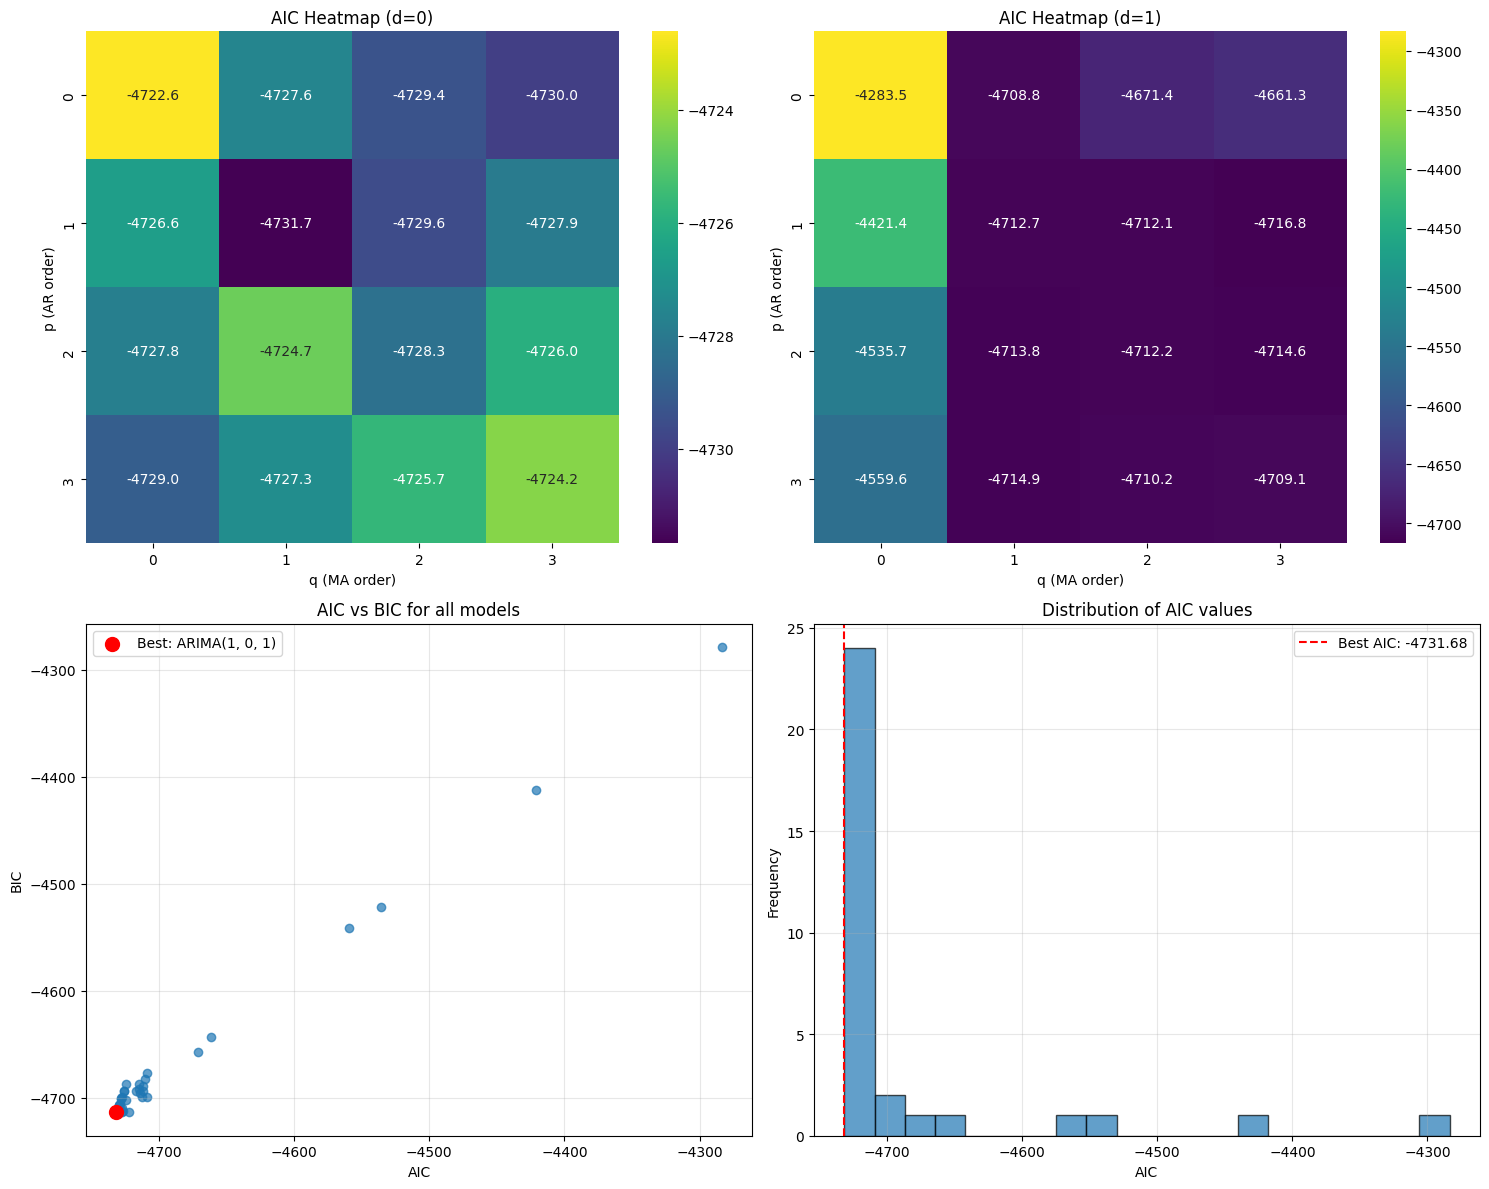

In [13]:
# Visualize grid search results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. AIC heatmap for different p,q combinations (d=0)
if len(results_df[results_df['d'] == 0]) > 0:
    pivot_aic_d0 = results_df[results_df['d'] == 0].pivot(index='p', columns='q', values='aic')
    sns.heatmap(pivot_aic_d0, annot=True, fmt='.1f', cmap='viridis', ax=axes[0,0])
    axes[0,0].set_title('AIC Heatmap (d=0)')
    axes[0,0].set_xlabel('q (MA order)')
    axes[0,0].set_ylabel('p (AR order)')

# 2. AIC heatmap for different p,q combinations (d=1) 
if len(results_df[results_df['d'] == 1]) > 0:
    pivot_aic_d1 = results_df[results_df['d'] == 1].pivot(index='p', columns='q', values='aic')
    sns.heatmap(pivot_aic_d1, annot=True, fmt='.1f', cmap='viridis', ax=axes[0,1])
    axes[0,1].set_title('AIC Heatmap (d=1)')
    axes[0,1].set_xlabel('q (MA order)')
    axes[0,1].set_ylabel('p (AR order)')

# 3. AIC vs BIC scatter plot
axes[1,0].scatter(results_df['aic'], results_df['bic'], alpha=0.7)
# Highlight best model
best_row = results_df[(results_df['p'] == best_params[0]) & 
                     (results_df['d'] == best_params[1]) & 
                     (results_df['q'] == best_params[2])]
if len(best_row) > 0:
    axes[1,0].scatter(best_row['aic'], best_row['bic'], color='red', s=100, 
                     label=f'Best: ARIMA{best_params}', zorder=5)
    axes[1,0].legend()
axes[1,0].set_xlabel('AIC')
axes[1,0].set_ylabel('BIC')
axes[1,0].set_title('AIC vs BIC for all models')
axes[1,0].grid(True, alpha=0.3)

# 4. Distribution of AIC values
axes[1,1].hist(results_df['aic'], bins=20, alpha=0.7, edgecolor='black')
axes[1,1].axvline(results_df['aic'].min(), color='red', linestyle='--', 
                 label=f'Best AIC: {results_df["aic"].min():.2f}')
axes[1,1].set_xlabel('AIC')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of AIC values')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Model Diagnostics for Best ARIMA Model

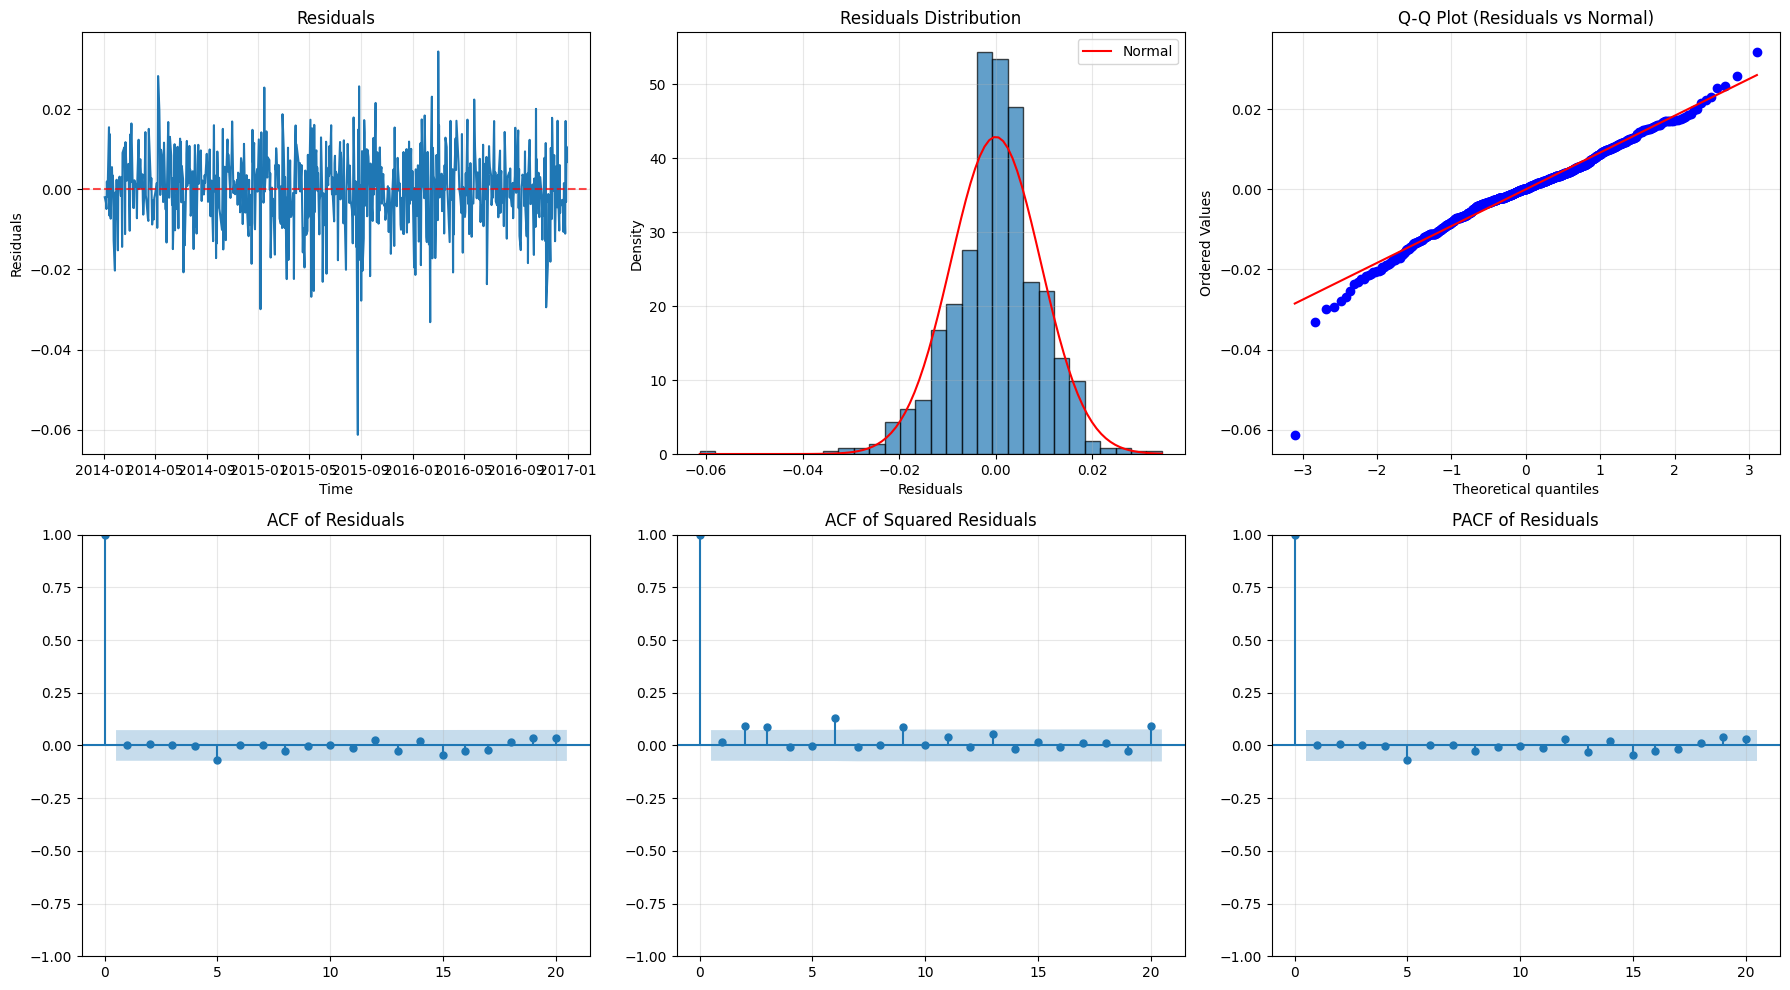


Residual Diagnostics:

Ljung-Box Test (Serial Correlation):
H0: No serial correlation in residuals
Significant lags (p < 0.05): []
✅ No evidence of serial correlation

Ljung-Box Test on Squared Residuals (ARCH Effects):
H0: No ARCH effects
Significant lags (p < 0.05): [2, 3, 4, 5, 6, 7, 8, 9, 10]
⚠️ Warning: Evidence of ARCH effects (consider GARCH model)

Shapiro-Wilk Normality Test:
Statistic: 0.9737, p-value: 0.000000
⚠️ Warning: Residuals are not normally distributed

Residual Summary Statistics:
Mean: 0.000001
Std: 0.009297
Skewness: -0.5386
Kurtosis: 5.9734


In [14]:
# Model diagnostics
residuals = best_model.resid

# Create diagnostic plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals plot
axes[0,0].plot(residuals)
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0,0].set_title('Residuals')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Residuals')
axes[0,0].grid(True, alpha=0.3)

# 2. Residuals histogram
axes[0,1].hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Residuals Distribution')
axes[0,1].set_xlabel('Residuals')
axes[0,1].set_ylabel('Density')
# Overlay normal distribution
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
y_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
axes[0,1].plot(x_norm, y_norm, 'r-', label='Normal')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot (Residuals vs Normal)')
axes[0,2].grid(True, alpha=0.3)

# 4. ACF of residuals
plot_acf(residuals, lags=20, ax=axes[1,0], zero=True)
axes[1,0].set_title('ACF of Residuals')
axes[1,0].grid(True, alpha=0.3)

# 5. ACF of squared residuals
plot_acf(residuals**2, lags=20, ax=axes[1,1], zero=True)
axes[1,1].set_title('ACF of Squared Residuals')
axes[1,1].grid(True, alpha=0.3)

# 6. PACF of residuals
plot_pacf(residuals, lags=20, ax=axes[1,2], method='ywm')
axes[1,2].set_title('PACF of Residuals')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests on residuals
print("\nResidual Diagnostics:")
print("=" * 30)

# Ljung-Box test for serial correlation
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print("\nLjung-Box Test (Serial Correlation):")
print(f"H0: No serial correlation in residuals")
print(f"Significant lags (p < 0.05): {list(lb_test[lb_test['lb_pvalue'] < 0.05].index)}")
if lb_test['lb_pvalue'].min() < 0.05:
    print("⚠️ Warning: Evidence of serial correlation in residuals")
else:
    print("✅ No evidence of serial correlation")

# Ljung-Box test on squared residuals (ARCH effects)
lb_test_sq = acorr_ljungbox(residuals**2, lags=10, return_df=True)
print("\nLjung-Box Test on Squared Residuals (ARCH Effects):")
print(f"H0: No ARCH effects")
print(f"Significant lags (p < 0.05): {list(lb_test_sq[lb_test_sq['lb_pvalue'] < 0.05].index)}")
if lb_test_sq['lb_pvalue'].min() < 0.05:
    print("⚠️ Warning: Evidence of ARCH effects (consider GARCH model)")
else:
    print("✅ No evidence of ARCH effects")

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Normality Test:")
print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.6f}")
if shapiro_p < 0.05:
    print("⚠️ Warning: Residuals are not normally distributed")
else:
    print("✅ Residuals appear normally distributed")

# Summary statistics
print(f"\nResidual Summary Statistics:")
print(f"Mean: {residuals.mean():.6f}")
print(f"Std: {residuals.std():.6f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals, fisher=False):.4f}")

### Forecasting with Best ARIMA Model

Debug Info:
Forecast steps: 30
Forecast mean shape: (30,)
Forecast CI shape: (30, 2)
Forecast mean type: <class 'pandas.core.series.Series'>
Processed forecast values shape: (30,)
CI lower shape: (30,)
CI upper shape: (30,)
After validation - shapes: forecast=(30,), ci_lower=(30,), ci_upper=(30,)
Forecast dates length: 30
Last date: 2016-12-30 00:00:00
First forecast date: 2016-12-31 00:00:00
log_price_last type: <class 'float'>, value: 9.010156200936967
cumulative_log_returns type: <class 'numpy.ndarray'>, shape: (30,)
forecasted_log_prices type: <class 'numpy.ndarray'>, shape: (30,)
forecasted_prices type: <class 'numpy.ndarray'>, shape: (30,)
Forecasted prices shape: (30,)
Price CI shapes: (30,), (30,)


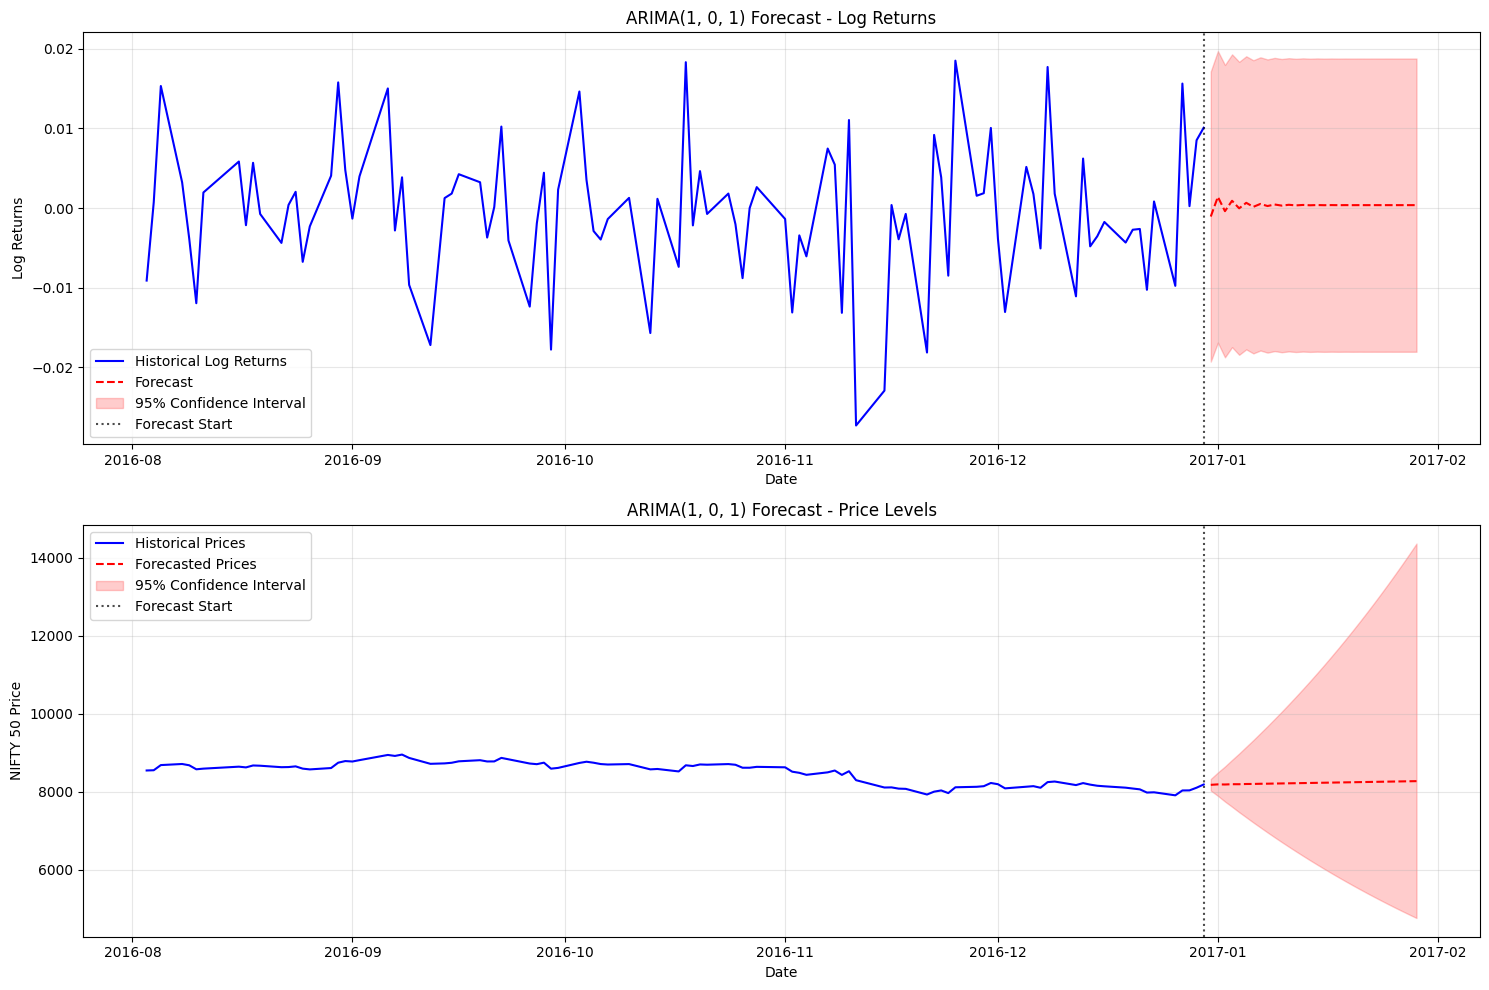


Forecast Summary (Next 30 days):
Current NIFTY 50 Price: 8185.80
Forecasted Price Range: 8177.17 - 8271.59
Expected Price in 30 days: 8271.59
Expected Return over 30 days: 1.05%
DataFrame shape: (30, 7)
Column lengths: [30, 30, 30, 30, 30, 30, 30]

Detailed Forecast (First 10 days):


,Date,Forecasted_Log_Return,Lower_CI_Log_Return,Upper_CI_Log_Return,Forecasted_Price,Lower_CI_Price,Upper_CI_Price
0,2016-12-31,-0.0011,-0.0193,0.0172,8177.1678,8029.6418,8327.4042
1,2017-01-01,0.0014,-0.0169,0.0197,8188.7498,7895.2169,8493.1958
2,2017-01-02,-0.0004,-0.0187,0.0180,8185.6262,7748.7287,8647.1574
3,2017-01-03,0.0009,-0.0174,0.0193,8193.2053,7614.7091,8815.6503
4,2017-01-04,-0.0000,-0.0184,0.0184,8192.9990,7475.7957,8979.0084
5,2017-01-05,0.0007,-0.0177,0.0191,8198.4596,7344.4404,9151.7851
6,2017-01-06,0.0002,-0.0182,0.0186,8199.7989,7211.7379,9323.2316
7,2017-01-07,0.0005,-0.0179,0.0189,8204.1391,7084.0098,9501.3841
8,2017-01-08,0.0003,-0.0181,0.0187,8206.2977,6956.6852,9680.3751
9,2017-01-09,0.0005,-0.0179,0.0189,8210.0457,6832.9676,9864.6524


In [15]:
# Generate forecasts
forecast_steps = 30  # Forecast 30 days ahead

# Generate point forecasts and confidence intervals
forecast = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Debug: Print shapes to identify the issue
print(f"Debug Info:")
print(f"Forecast steps: {forecast_steps}")
print(f"Forecast mean shape: {forecast_mean.shape}")
print(f"Forecast CI shape: {forecast_ci.shape}")
print(f"Forecast mean type: {type(forecast_mean)}")

# Ensure forecast_mean is a 1D array/Series
if hasattr(forecast_mean, 'values'):
    forecast_values = forecast_mean.values.flatten()
else:
    forecast_values = np.array(forecast_mean).flatten()

# Ensure confidence intervals are properly shaped
if hasattr(forecast_ci, 'values'):
    ci_lower = forecast_ci.iloc[:, 0].values.flatten()
    ci_upper = forecast_ci.iloc[:, 1].values.flatten()
else:
    ci_lower = forecast_ci[:, 0].flatten()
    ci_upper = forecast_ci[:, 1].flatten()

print(f"Processed forecast values shape: {forecast_values.shape}")
print(f"CI lower shape: {ci_lower.shape}")
print(f"CI upper shape: {ci_upper.shape}")

# Validate all arrays are 1D numpy arrays
forecast_values = np.array(forecast_values).flatten()
ci_lower = np.array(ci_lower).flatten()
ci_upper = np.array(ci_upper).flatten()

print(f"After validation - shapes: forecast={forecast_values.shape}, ci_lower={ci_lower.shape}, ci_upper={ci_upper.shape}")

# Create forecast dates
last_date = data_for_modeling.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
                              periods=len(forecast_values), freq='D')

print(f"Forecast dates length: {len(forecast_dates)}")
print(f"Last date: {last_date}")
print(f"First forecast date: {forecast_dates[0]}")

# Ensure all arrays have the same length
assert len(forecast_values) == len(ci_lower) == len(ci_upper) == len(forecast_dates), \
    f"Length mismatch: forecast={len(forecast_values)}, ci_lower={len(ci_lower)}, ci_upper={len(ci_upper)}, dates={len(forecast_dates)}"

# Plot historical data and forecasts
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Log returns with forecasts
last_100_days = data_for_modeling.tail(100)
axes[0].plot(last_100_days.index, last_100_days, label='Historical Log Returns', color='blue')
axes[0].plot(forecast_dates, forecast_values, label='Forecast', color='red', linestyle='--')
axes[0].fill_between(forecast_dates, ci_lower, ci_upper, 
                    color='red', alpha=0.2, label='95% Confidence Interval')
axes[0].axvline(last_date, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
axes[0].set_title(f'ARIMA{best_params} Forecast - Log Returns')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Price level forecasts (convert back from log returns)
last_price = float(df['Close'].iloc[-1])  # Ensure it's a scalar
log_price_last = float(np.log(last_price))  # Ensure it's a scalar

# Convert forecasted log returns to price levels
cumulative_log_returns = np.cumsum(forecast_values)
forecasted_log_prices = log_price_last + cumulative_log_returns
forecasted_prices = np.exp(forecasted_log_prices)

# Confidence intervals for prices  
cumulative_ci_lower = log_price_last + np.cumsum(ci_lower)
cumulative_ci_upper = log_price_last + np.cumsum(ci_upper)
ci_prices_lower = np.exp(cumulative_ci_lower)
ci_prices_upper = np.exp(cumulative_ci_upper)

# Debug: Check types and shapes
print(f"log_price_last type: {type(log_price_last)}, value: {log_price_last}")
print(f"cumulative_log_returns type: {type(cumulative_log_returns)}, shape: {cumulative_log_returns.shape}")
print(f"forecasted_log_prices type: {type(forecasted_log_prices)}, shape: {forecasted_log_prices.shape}")
print(f"forecasted_prices type: {type(forecasted_prices)}, shape: {forecasted_prices.shape}")

print(f"Forecasted prices shape: {forecasted_prices.shape}")
print(f"Price CI shapes: {ci_prices_lower.shape}, {ci_prices_upper.shape}")

# Plot historical prices and forecasted prices
last_100_prices = df['Close'].tail(100)
axes[1].plot(last_100_prices.index, last_100_prices, label='Historical Prices', color='blue')
axes[1].plot(forecast_dates, forecasted_prices, label='Forecasted Prices', color='red', linestyle='--')
axes[1].fill_between(forecast_dates, ci_prices_lower, ci_prices_upper, 
                    color='red', alpha=0.2, label='95% Confidence Interval')
axes[1].axvline(last_date, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
axes[1].set_title(f'ARIMA{best_params} Forecast - Price Levels')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('NIFTY 50 Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display forecast summary
actual_forecast_days = len(forecast_values)
print(f"\nForecast Summary (Next {actual_forecast_days} days):")
print("=" * 50)
print(f"Current NIFTY 50 Price: {last_price:.2f}")
print(f"Forecasted Price Range: {forecasted_prices.min():.2f} - {forecasted_prices.max():.2f}")
print(f"Expected Price in {actual_forecast_days} days: {forecasted_prices[-1]:.2f}")
print(f"Expected Return over {actual_forecast_days} days: {((forecasted_prices[-1]/last_price) - 1)*100:.2f}%")

# Create forecast DataFrame - ensure all arrays are numpy arrays
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Log_Return': np.array(forecast_values).flatten(),
    'Lower_CI_Log_Return': np.array(ci_lower).flatten(),
    'Upper_CI_Log_Return': np.array(ci_upper).flatten(),
    'Forecasted_Price': np.array(forecasted_prices).flatten(),
    'Lower_CI_Price': np.array(ci_prices_lower).flatten(),
    'Upper_CI_Price': np.array(ci_prices_upper).flatten()
})

# Debug DataFrame creation
print(f"DataFrame shape: {forecast_df.shape}")
print(f"Column lengths: {[len(forecast_df[col]) for col in forecast_df.columns]}")

print("\nDetailed Forecast (First 10 days):")
display(forecast_df.head(10).round(4))

### Summary and Results

In [16]:
# Final Summary
print("ARIMA Grid Search Summary")
print("=" * 40)
print(f"\n📊 Data Overview:")
print(f"  • Time Period: {START} to {END}")
print(f"  • Total Observations: {len(data_for_modeling)}")
print(f"  • Data Used: Log Returns")

print(f"\n🔍 Grid Search Results:")
print(f"  • Parameter Combinations Tested: {len(results_df)}")
print(f"  • Best Model: ARIMA{best_params}")
print(f"  • Best AIC: {results_df['aic'].min():.4f}")

print(f"\n📈 Forecast Results:")
print(f"  • Forecast Horizon: {actual_forecast_days} days")
print(f"  • Current Price: ₹{last_price:.2f}")
print(f"  • Expected Price in {actual_forecast_days} days: ₹{forecasted_prices[-1]:.2f}")
print(f"  • Expected {actual_forecast_days}-day Return: {((forecasted_prices[-1]/last_price) - 1)*100:.2f}%")

# Save results
output_file = os.path.join(OUT_DIR, 'arima_grid_search_results.csv')
results_df.to_csv(output_file, index=False)
print(f"\n💾 Grid search results saved to: {output_file}")

forecast_file = os.path.join(OUT_DIR, 'arima_forecasts.csv') 
forecast_df.to_csv(forecast_file, index=False)
print(f"💾 Forecasts saved to: {forecast_file}")

print(f"\n🎯 Model Quality Assessment:")
print(f"  • Residual Mean: {residuals.mean():.6f}")
print(f"  • Residual Std: {residuals.std():.6f}")
print(f"  • Serial Correlation Test: {'PASS' if lb_test['lb_pvalue'].min() > 0.05 else 'FAIL'}")
print(f"  • ARCH Effects Test: {'PASS' if lb_test_sq['lb_pvalue'].min() > 0.05 else 'FAIL'}")
print(f"  • Normality Test: {'PASS' if shapiro_p > 0.05 else 'FAIL'}")

print(f"\n📝 Next Steps:")
print(f"  1. Validate model on out-of-sample data")
print(f"  2. Consider GARCH models if ARCH effects detected")
print(f"  3. Monitor forecast accuracy over time")
print(f"  4. Update model regularly with new data")
print(f"  5. Consider ensemble methods for robustness")

ARIMA Grid Search Summary

📊 Data Overview:
  • Time Period: 2014-01-01 to 2016-12-31
  • Total Observations: 727
  • Data Used: Log Returns

🔍 Grid Search Results:
  • Parameter Combinations Tested: 32
  • Best Model: ARIMA(1, 0, 1)
  • Best AIC: -4731.6774

📈 Forecast Results:
  • Forecast Horizon: 30 days
  • Current Price: ₹8185.80
  • Expected Price in 30 days: ₹8271.59
  • Expected 30-day Return: 1.05%

💾 Grid search results saved to: ../data/arima_grid_search_results.csv
💾 Forecasts saved to: ../data/arima_forecasts.csv

🎯 Model Quality Assessment:
  • Residual Mean: 0.000001
  • Residual Std: 0.009297
  • Serial Correlation Test: PASS
  • ARCH Effects Test: FAIL
  • Normality Test: FAIL

📝 Next Steps:
  1. Validate model on out-of-sample data
  2. Consider GARCH models if ARCH effects detected
  3. Monitor forecast accuracy over time
  4. Update model regularly with new data
  5. Consider ensemble methods for robustness
